# KNN

En este notebook vamos a utilizar el algoritmo knn para predecir la categoria de servicio de un usuario dado en base a distintos features, buscamos entonces acomodar knn a un algoritmo de **decisión**.

### SETUP
Instalamos librerias y las importamos, descargamos y leemos dataset

In [1]:
!pip install -q numpy==2.2.0
!pip install -q pandas==2.2.3
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3
!pip install -q seaborn==0.13.2

In [1]:
#Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
%matplotlib inline

#Descargamos dataset
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')

## Estudio del Dataset

Analicemos los tipos del dataset y tomemos un sample 

In [2]:
print("---------TYPES-----------")
print(df.dtypes)
print("--------SAMPLE---------")
df.sample(2)

---------TYPES-----------
region       int64
tenure       int64
age          int64
marital      int64
address      int64
income     float64
ed           int64
employ       int64
retire     float64
gender       int64
reside       int64
custcat      int64
dtype: object
--------SAMPLE---------


,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
879,3,38,30,1,6,22.0,2,3,0.0,1,2,2
236,2,50,52,1,17,36.0,4,16,0.0,0,4,4


Podemos observar que todos los valores son numericos y por lo tanto no es necesario hacer mapeos ni transformaciones de momento.

## Correlaciones
Comencemos haciendo un grafico de correlaciones con la variable target `custcat` *(o customer category)* y definamos que campos nos serán útiles como features

In [3]:
correlation_values = abs(df.corr()['custcat'].drop('custcat')).sort_values(ascending=False)
correlation_values

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
region     0.023771
retire     0.008908
gender     0.004966
Name: custcat, dtype: float64

Gracias a esto es evidente que variables como `ed`, `tenure`, `income` y `employ` son las que más peso tienen sobre nuestro target y por lo tanto las que vamos a estar utilizando. <br> *Recordemos que, en el caso de knn, mas features no implica mejor accuracy, ver [Notas](./README.md)*

## Preprocesamiento 
Por ultimo, normalicemos nuestra data para impedir que las magnitudes afecten la precisión en las distnacias de cada datapoint y luego separemos en grupos de validación y entrenamiento. 

In [4]:
# Tomamos target y variables independientes
X = df.drop('custcat',axis=1)
Y = df['custcat']

#Normalizamos
X_norm = StandardScaler().fit_transform(X)


# Separamos en validacion y entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X_norm, Y, test_size=0.2, random_state=4)

## Preparación del Modelo

Armemos el modelo mediante el algoritmo de KNN y obtengmaos las predicciones


In [5]:
# Clasificador
knn_classifier = KNeighborsClassifier(n_neighbors=3)
# Modelo
model = knn_classifier.fit(X_train,y_train)

#Predicciones
y_hat = model.predict(X_test)

Ahora estudiemos las metricas obtenidas y si podria haberse mejorado su rendimiento en base al valor del "K"

In [9]:
print("Accuracy: ", accuracy_score(y_test, y_hat))

Accuracy:  0.315


Vemos que obtuvimos una precisión no muy buena, sin embargo es posible mejorarla aumentando el valor del K? Podemos plantear el siguiente gráfico:

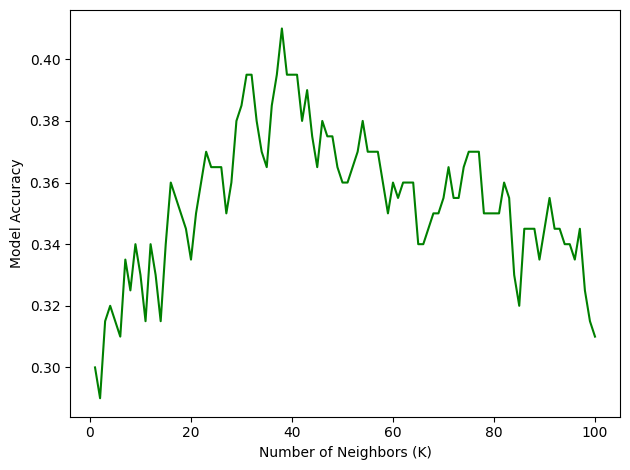

In [13]:
#Seteamos algun rango de K's
Ks = 100
acc = np.zeros((Ks))
for n in range(1,Ks+1):
    #Entrenamos y predecimos
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test, yhat)

plt.plot(range(1,Ks+1),acc,'g')
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

Esto nos muestra un pico de precisión en los valores de K cercanos a 37/38, sin embargo recordemos que esto trae un mayor costo computacional y que no siempre será efectivo, pues requiere una mayor cantidad de puntos para tomar una decisión, que en este caso simplemente nos lleva a una precisión del 40% (relativamente baja).